# Diffusion Models for Medical Anomaly Detection: Classifier and Classifier-Free Guidance

This tutorial demonstrates two ways to guide a diffusion model toward a **healthy reconstruction** of a 2D brain MR slice using MONAI:

1. **Classifier guidance**: a separate classifier provides gradients that steer DDIM denoising toward the healthy class.
2. **Classifier-free guidance (CFG)**: the diffusion model is trained with both class-conditioned and unconditioned examples, so no separate classifier is needed during sampling.

The model is trained on 2D axial slices from the BraTS/Medical Segmentation Decathlon brain-tumor dataset. An anomaly map is then obtained by comparing the original slice with its guided healthy reconstruction.

> **Label convention used in the code:** `0 = diseased` and `1 = healthy`. In the CFG section, class `2` is reserved as the **null / no-class** condition.

Reference: Wolleb et al., *Diffusion Models for Medical Anomaly Detection* (2022), https://arxiv.org/abs/2203.04306

## Setup environment


In [ ]:
import datetime
current_time = datetime.datetime.now()
print(current_time)

2026-08-13 11:52:49.452097


In [ ]:
!python -c "import monai" || pip install -q "monai-weekly[pillow, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
!python -c "import seaborn" || pip install -q seaborn

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.6 MB/s eta 0:00:00


## Setup imports

In [ ]:
# Standard library
import os
import time
import tempfile

# Scientific Python / PyTorch
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# MONAI
from monai import transforms
from monai.apps import DecathlonDataset
from monai.config import print_config
from monai.data import DataLoader
from monai.utils import set_determinism
from torch.amp import GradScaler, autocast
from tqdm import tqdm

from monai.inferers import DiffusionInferer
from monai.networks.nets.diffusion_model_unet import DiffusionModelEncoder, DiffusionModelUNet
from monai.networks.schedulers.ddim import DDIMScheduler

torch.multiprocessing.set_sharing_strategy("file_system")

print_config()


MONAI version: 1.7.dev2632
Numpy version: 2.0.2
Pytorch version: 2.11.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 5a454eec9f1b95c6e263b40f7d237f1fdf8f654c
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.20.0
gdown version: 5.2.2
TorchVision version: 0.26.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.13.1
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://monai.readth

## Setup data directory

In [ ]:
root_dir = 'data'
!mkdir {root_dir}

## Set deterministic training for reproducibility

In [ ]:
set_determinism(42)

## Pipeline at a glance

The workflow used in both guidance variants is:

1. Prepare 2D MRI slices and assign a healthy/diseased slice label.
2. Train a diffusion model to predict Gaussian noise at arbitrary timesteps.
3. Encode a diseased input slice partway into the diffusion trajectory using reversed DDIM steps.
4. Denoise toward the **healthy** class using either classifier guidance or classifier-free guidance.
5. Subtract the guided reconstruction from the original image to obtain an anomaly map.


## Preprocessing the BraTS dataset into 2D slices

The Medical Segmentation Decathlon brain-tumor data are 3D volumes. The transform pipeline below selects one MRI modality (FLAIR by default), standardizes orientation and spacing, center-crops the volume, normalizes intensities, and finally samples a single axial 2D slice.

For each sampled slice, the segmentation mask is collapsed to a binary **slice-level label**:

- `0` (**diseased**) if the segmentation mask contains any tumor voxel.
- `1` (**healthy**) if the segmentation mask is empty.

The key transforms are:

1. `LoadImaged` / `EnsureChannelFirstd`: load images and put channels first.
2. `Lambdad`: select the requested MRI modality.
3. `Orientationd` / `Spacingd`: standardize geometry.
4. `CenterSpatialCropd`: keep a consistent central field of view.
5. `ScaleIntensityRangePercentilesd`: map robust intensity percentiles to `[0, 1]`.
6. `RandSpatialCropd`: draw one `64 × 64 × 1` slice.
7. `CopyItemsd` + `Lambdad`: convert the segmentation mask to the binary slice label described above.


In [ ]:
channel = 0  # MRI modality index; 0 corresponds to FLAIR in this dataset
assert channel in [0, 1, 2, 3], "Choose a valid channel"

train_transforms = transforms.Compose(
    [
        transforms.LoadImaged(keys=["image", "label"]),
        transforms.EnsureChannelFirstd(keys=["image", "label"]),
        transforms.Lambdad(keys=["image"], func=lambda x: x[channel, :, :, :]),
        transforms.EnsureChannelFirstd(keys=["image"], channel_dim="no_channel"),
        transforms.EnsureTyped(keys=["image", "label"]),
        transforms.Orientationd(keys=["image", "label"], axcodes="RAS"),
        transforms.Spacingd(keys=["image", "label"], pixdim=(3.0, 3.0, 2.0), mode=("bilinear", "nearest")),
        transforms.CenterSpatialCropd(keys=["image", "label"], roi_size=(64, 64, 44)),
        transforms.ScaleIntensityRangePercentilesd(keys="image", lower=0, upper=99.5, b_min=0, b_max=1),
        transforms.RandSpatialCropd(keys=["image", "label"], roi_size=(64, 64, 1), random_size=False),
        transforms.Lambdad(keys=["image", "label"], func=lambda x: x.squeeze(-1)),
        transforms.CopyItemsd(keys=["label"], times=1, names=["slice_label"]),
        transforms.Lambdad(
            keys=["slice_label"],
            # 0 = tumor present (diseased), 1 = no tumor pixels (healthy)
            func=lambda x: 0.0 if x.sum() > 0 else 1.0,
        ),
    ]
)


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:320: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [ ]:
batch_size = 64

train_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task01_BrainTumour",
    section="training",  # validation
    cache_rate=1.0,  # you may need a few Gb of RAM... Set to 0 otherwise
    num_workers=4,
    download=True,  # Set download to True if the dataset hasn't been downloaded yet
    seed=0,
    transform=train_transforms,
)

print(f"Length of training data: {len(train_ds)}")  # this gives the number of patients in the training set
print(f'Train image shape {train_ds[0]["image"].shape}')

train_loader = DataLoader(
    train_ds, batch_size=batch_size, shuffle=True, num_workers=4, drop_last=True, persistent_workers=True
)

Task01_BrainTumour.tar: 7.09GB [08:44, 14.5MB/s]                            


2026-08-12 18:30:00,169 - INFO - Verified 'Task01_BrainTumour.tar', md5: 240a19d752f0d9e9101544901065d872.
2026-08-12 18:30:00,171 - INFO - Downloaded: data/Task01_BrainTumour.tar
2026-08-12 18:30:00,173 - INFO - Writing into directory: data.


Loading dataset: 100%|██████████| 388/388 [07:10<00:00,  1.11s/it]

Length of training data: 388
Train image shape torch.Size([1, 64, 64])



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Preprocessing of the BRATS Dataset in 2D slices for validation
We download the BRATS validation dataset from the Decathlon dataset, and define the dataloader to load 2D slices for validation.



In [ ]:
val_ds = DecathlonDataset(
    root_dir=root_dir,
    task="Task01_BrainTumour",
    section="validation",
    cache_rate=1.0,  # you may need a few Gb of RAM... Set to 0 otherwise
    num_workers=4,
    download=True,  # Set download to True if the dataset hasn't been downloaded yet
    seed=0,
    transform=train_transforms,
)
print(f"Length of validation data: {len(val_ds)}")
print(f'Validation Image shape {val_ds[0]["image"].shape}')

val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False, num_workers=4, drop_last=True, persistent_workers=True
)


2026-08-12 18:38:18,108 - INFO - Verified 'Task01_BrainTumour.tar', md5: 240a19d752f0d9e9101544901065d872.
2026-08-12 18:38:18,109 - INFO - File exists: data/Task01_BrainTumour.tar, skipped downloading.
2026-08-12 18:38:18,112 - INFO - Non-empty folder exists in data/Task01_BrainTumour, skipped extracting.


Loading dataset: 100%|██████████| 96/96 [01:47<00:00,  1.12s/it]

Length of training data: 96
Validation Image shape torch.Size([1, 64, 64])


## Part I — Classifier-guided diffusion

### Define the diffusion network, scheduler, optimizer, and inferer

The first approach trains an **unconditional** 2D diffusion model and a separate classifier. During sampling, the classifier gradient steers the denoising trajectory toward the healthy class.

The diffusion backbone is a 2D U-Net. `DDIMScheduler` defines the diffusion/noise schedule and the deterministic DDIM sampling updates, while `DiffusionInferer` provides MONAI's training and sampling interface.


In [ ]:
device = torch.device("cuda")

model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(64, 64, 64),
    attention_levels=(False, False, True),
    num_res_blocks=1,
    num_head_channels=64,
    with_conditioning=False,
)
model.to(device)

# Forward diffusion is defined over 1,000 training timesteps.
scheduler = DDIMScheduler(num_train_timesteps=1000)

# The model learns to predict the noise added at a randomly sampled timestep.
optimizer = torch.optim.Adam(params=model.parameters(), lr=2.5e-5)

inferer = DiffusionInferer(scheduler)


### Train the diffusion model

At a randomly sampled timestep $t$, Gaussian noise $\epsilon \sim \mathcal{N}(0,I)$ is added to a clean image $x_0$:

$$
x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon.
$$

The U-Net predicts the injected noise, $\epsilon_\theta(x_t,t)$. Training minimizes the standard noise-prediction objective:

$$
\mathcal{L}_{\text{diff}} = \mathbb{E}_{x_0,t,\epsilon}\left[\lVert \epsilon - \epsilon_\theta(x_t,t) \rVert_2^2\right].
$$

The notebook uses 800 epochs and mixed precision. This is computationally expensive; for experimentation, reducing the epoch count is reasonable.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 0 Validation loss 0.49015703797340393
Epoch 20 Validation loss 0.22860252857208252
Epoch 40 Validation loss 0.08123321086168289
Epoch 60 Validation loss 0.03477764129638672
Epoch 80 Validation loss 0.01947544887661934
Epoch 100 Validation loss 0.013005109503865242
Epoch 120 Validation loss 0.016996977850794792
Epoch 140 Validation loss 0.0074701206758618355
Epoch 160 Validation loss 0.011830434203147888
Epoch 180 Validation loss 0.016883105039596558
Epoch 200 Validation loss 0.010918458923697472
Epoch 220 Validation loss 0.010576395317912102
Epoch 240 Validation loss 0.012438306584954262
Epoch 260 Validation loss 0.008401199243962765
Epoch 280 Validation loss 0.010650603100657463
Epoch 300 Validation loss 0.010506544262170792
Epoch 320 Validation loss 0.006741183344274759
Epoch 340 Validation loss 0.014951830729842186
Epoch 360 Validation loss 0.006716431118547916
Epoch 380 Validation loss 0.00786742102354765
Epoch 400 Validation loss 0.009064931422472
Epoch 420 Validation loss 0

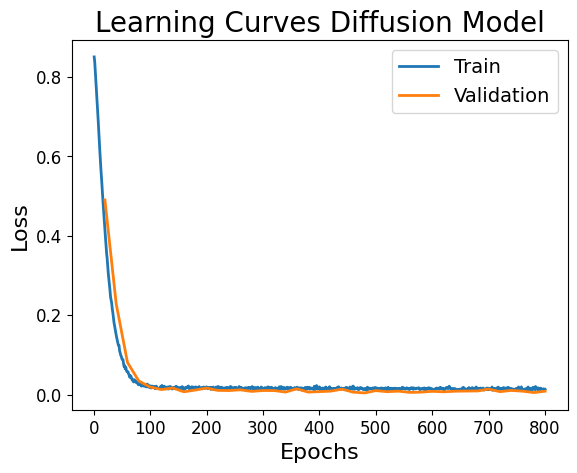

In [ ]:
max_epochs = 800
val_interval = 20
epoch_loss_list = []
val_epoch_loss_list = []

scaler = GradScaler()
total_start = time.time()

for epoch in range(max_epochs):
    model.train()
    len_train_loader = len(train_loader)
    epoch_loss = 0

    for data in train_loader:
        images = data["image"].to(device)
        classes = data["slice_label"].to(device)  # retained for symmetry; diffusion training itself is unconditional
        optimizer.zero_grad(set_to_none=True)
        timesteps = torch.randint(0, 1000, (len(images),)).to(device)  # pick a random timestep

        with autocast(enabled=True, device_type="cuda"):
            # Sample the exact noise that the network will be trained to recover
            noise = torch.randn_like(images).to(device)

            # Predict epsilon from x_t and t
            noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)
            loss = F.mse_loss(noise_pred.float(), noise.float())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()
    epoch_loss_list.append(epoch_loss / (len_train_loader + 1))

    if epoch % val_interval == 0:
        model.eval()
        len_val_loader = len(val_loader)
        val_epoch_loss = 0

        for data in val_loader:
            images = data["image"].to(device)
            classes = data["slice_label"].to(device)
            timesteps = torch.randint(0, 1000, (len(images),)).to(device)
            with torch.no_grad():
                with autocast(enabled=True, device_type="cuda"):
                    noise = torch.randn_like(images).to(device)
                    noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)
                    val_loss = F.mse_loss(noise_pred.float(), noise.float())

            val_epoch_loss += val_loss.item()
        val_epoch_loss_list.append(val_epoch_loss / (len_val_loader + 1))
        print("Epoch", epoch, "Validation loss", val_epoch_loss / (len_val_loader + 1))

total_time = time.time() - total_start
print(f"train diffusion completed, total time: {total_time}.")

plt.style.use("default")
plt.title("Learning Curves Diffusion Model", fontsize=20)
plt.plot(np.linspace(1, max_epochs, max_epochs), epoch_loss_list, color="C0", linewidth=2.0, label="Train")
plt.plot(
    np.linspace(val_interval, max_epochs, int(max_epochs / val_interval)),
    val_epoch_loss_list,
    color="C1",
    linewidth=2.0,
    label="Validation",
)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.legend(prop={"size": 14})
plt.show()


## Check the performance of the diffusion model

We generate a random image from noise to check whether our diffusion model works properly for an image generation task.



100%|██████████| 1000/1000 [00:19<00:00, 50.13it/s]


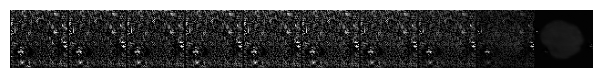

In [ ]:
model.eval()
noise = torch.randn((1, 1, 64, 64))
noise = noise.to(device)
scheduler.set_timesteps(num_inference_steps=1000)
with autocast(enabled=True, device_type="cuda"):
    image, intermediates = inferer.sample(
        input_noise=noise, diffusion_model=model, scheduler=scheduler, save_intermediates=True, intermediate_steps=100
    )

chain = torch.cat(intermediates, dim=-1)

plt.style.use("default")
plt.imshow(chain[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.show()

## Train a noisy-image classifier for guidance

The classifier uses a diffusion-style encoder and receives both the noisy image $x_t$ and the timestep $t$. It predicts whether a slice is diseased (`0`) or healthy (`1`). Training it across noise levels is important because, during guided denoising, the classifier will see partially denoised samples rather than only clean images.

For logits $z_\phi(x_t,t)$, the classifier is trained with cross-entropy:

$$
\mathcal{L}_{\text{cls}} = -\log p_\phi(y\mid x_t,t).
$$


In [ ]:
device = torch.device("cuda")
classifier = DiffusionModelEncoder(
    spatial_dims=2,
    in_channels=1,
    out_channels=2,
    channels=(32, 64, 64),
    attention_levels=(False, True, True),
    num_res_blocks=(1, 1, 1),
    num_head_channels=64,
    with_conditioning=False,
)

classifier.to(device)

DiffusionModelEncoder(
  (conv_in): Convolution(
    (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0): DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 32, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler): Diffusion

## Model training of the classification model
We train our classification model for 1000 epochs.


Epoch 9 Validation loss 0.2444707751274109
Epoch 19 Validation loss 0.2844501733779907
Epoch 29 Validation loss 0.209311380982399
Epoch 39 Validation loss 0.1575915813446045
Epoch 49 Validation loss 0.17491045594215393
Epoch 59 Validation loss 0.14045704901218414
Epoch 69 Validation loss 0.13946962356567383
Epoch 79 Validation loss 0.11771580576896667
Epoch 89 Validation loss 0.13300445675849915
Epoch 99 Validation loss 0.18975549936294556
Epoch 109 Validation loss 0.0848136693239212
Epoch 119 Validation loss 0.16286274790763855
Epoch 129 Validation loss 0.11404098570346832
Epoch 139 Validation loss 0.13027410209178925
Epoch 149 Validation loss 0.17463085055351257
Epoch 159 Validation loss 0.12158595025539398
Epoch 169 Validation loss 0.11227664351463318
Epoch 179 Validation loss 0.15868598222732544
Epoch 189 Validation loss 0.15956631302833557
Epoch 199 Validation loss 0.14702282845973969
Epoch 209 Validation loss 0.1446194052696228
Epoch 219 Validation loss 0.18400421738624573
Epoch 

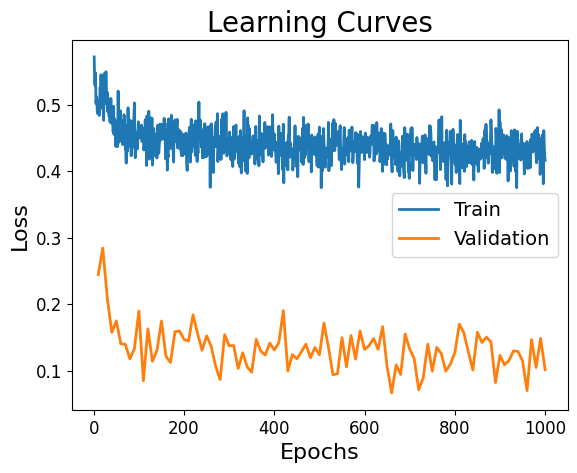

In [ ]:
max_epochs = 1000
val_interval = 10
epoch_loss_list = []
val_epoch_loss_list = []
optimizer_cls = torch.optim.Adam(params=classifier.parameters(), lr=2.5e-5)


scaler = GradScaler()
total_start = time.time()
for epoch in range(max_epochs):
    classifier.train()
    len_train_loader = len(train_loader)
    epoch_loss = 0

    for data in train_loader:
        images = data["image"].to(device)
        classes = data["slice_label"].to(device)

        optimizer_cls.zero_grad(set_to_none=True)
        timesteps = torch.randint(0, 1000, (len(images),)).to(device)

        with autocast(enabled=False, device_type="cuda"):
            # Corrupt each clean slice to a random diffusion timestep
            noise = torch.randn_like(images).to(device)

            # Predict the slice class from the noisy image and its timestep
            noisy_img = scheduler.add_noise(images, noise, timesteps)  # add t steps of noise to the input image
            pred = classifier(noisy_img, timesteps)

            loss = F.cross_entropy(pred, classes.long())

            loss.backward()
            optimizer_cls.step()

        epoch_loss += loss.item()
    epoch_loss_list.append(epoch_loss / (len_train_loader + 1))

    if (epoch + 1) % val_interval == 0:
        classifier.eval()
        len_val_loader = len(val_loader)
        val_epoch_loss = 0

        for data_val in val_loader:
            images = data_val["image"].to(device)
            classes = data_val["slice_label"].to(device)
            timesteps = torch.randint(0, 1, (len(images),)).to(
                device
            )  # check validation accuracy on the original images, i.e., do not add noise

            with torch.no_grad():
                with autocast(enabled=False, device_type="cuda"):
                    noise = torch.randn_like(images).to(device)
                    pred = classifier(images, timesteps)
                    val_loss = F.cross_entropy(pred, classes.long(), reduction="mean")

            val_epoch_loss += val_loss.item()
            _, predicted = torch.max(pred, 1)

        # Store one validation value per validation epoch (so it aligns with the plot x-axis).
        val_epoch_loss_list.append(val_epoch_loss / (len_val_loader + 1))
        print("Epoch", epoch, "Validation loss", val_epoch_loss / (len_val_loader + 1))

total_time = time.time() - total_start
print(f"train completed, total time: {total_time}.")

# Learning curves for the Classifier

plt.style.use("default")
plt.title("Learning Curves", fontsize=20)
plt.plot(np.linspace(1, max_epochs, max_epochs), epoch_loss_list, color="C0", linewidth=2.0, label="Train")
plt.plot(
    np.linspace(val_interval, max_epochs, int(max_epochs / val_interval)),
    val_epoch_loss_list,
    color="C1",
    linewidth=2.0,
    label="Validation",
)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.legend(prop={"size": 14})
plt.show()


## Image-to-image translation toward a healthy reconstruction

We now choose a diseased validation slice and transform it toward the **healthy** class. The procedure has two stages:

1. **DDIM inversion / encoding:** move the input partway along the diffusion trajectory to obtain a noisy latent representation.
2. **Guided DDIM denoising:** reverse that trajectory while steering each step toward the healthy class.

The hope is that anatomy unrelated to the lesion is preserved while tumor-related structure is removed or reduced.


minmax metatensor(0.) metatensor(1.2078)


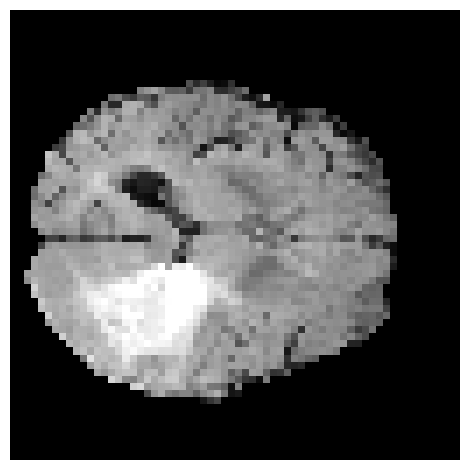

In [ ]:
data_val = next(iter(val_loader))  # explicitly fetch a validation batch for reconstruction
idx_unhealthy = np.argwhere(data_val["slice_label"].numpy() == 0).squeeze()
idx = idx_unhealthy[4]  # choose one diseased slice from this validation batch
inputimg = data_val["image"][idx]  # Pick an input slice of the validation set to be transformed
inputlabel = data_val["slice_label"][idx]  # Check whether it is healthy or diseased
print("minmax", inputimg.min(), inputimg.max())

plt.figure("input" + str(inputlabel))
plt.imshow(inputimg[0, ...], vmin=0, vmax=1, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

model.eval()
classifier.eval()


### Encode the input with reversed DDIM sampling

Before applying guidance, the input slice is moved $L$ steps toward a noisier state using the scheduler's reversed DDIM update. This is often called **DDIM inversion**.

Conceptually, the goal is to obtain a noisy state $x_L$ that still retains enough information about the original anatomy to be reconstructed, while giving the guided reverse process room to alter disease-related features. Here, `L = 200`; larger values generally allow more freedom to change the image but may reduce faithfulness to the input.

This step follows the inversion idea used in Wolleb et al. (Eq. 6).


100%|██████████| 200/200 [00:05<00:00, 33.36it/s]


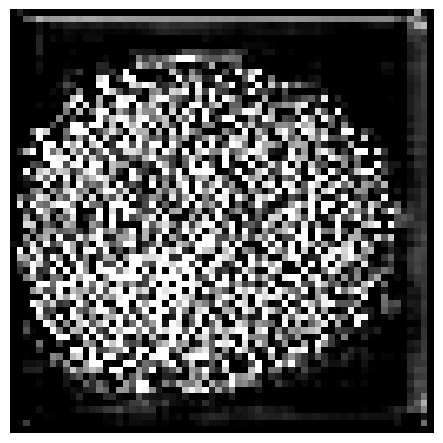

In [ ]:
L = 200
current_img = inputimg[None, ...].to(device)
scheduler.set_timesteps(num_inference_steps=1000)

progress_bar = tqdm(range(L))  # go back and forth L timesteps
for t in progress_bar:  # go through the noising process
    with autocast(enabled=False, device_type="cuda"):
        with torch.no_grad():
            model_output = model(current_img, timesteps=torch.Tensor((t,)).to(current_img.device))
    current_img, _ = scheduler.reversed_step(model_output, t, current_img)

plt.style.use("default")
plt.imshow(current_img[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.show()

### Denoise with classifier guidance

At each reverse step, the classifier contributes the gradient of the healthy-class log probability with respect to the current image. In the noise-prediction parameterization used here, the guided estimate is

$$
\hat{\epsilon}(x_t,t)
=
\epsilon_\theta(x_t,t)
-
s\sqrt{1-\bar{\alpha}_t}\,
\nabla_{x_t}\log p_\phi(y\mid x_t,t),
$$

where $s$ is the guidance scale. Because this notebook defines `0 = diseased` and `1 = healthy`, the code below uses `y = 1` as the guidance target.

> **Interpretation:** larger $s$ makes the classifier exert more influence, but excessive guidance can introduce artifacts or move the reconstruction too far from the original anatomy.


100%|██████████| 200/200 [00:12<00:00, 16.66it/s]


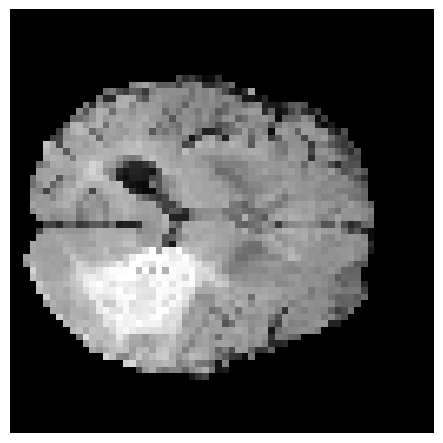

In [ ]:
y = torch.tensor(1, device=device)  # target class: healthy (0 = diseased, 1 = healthy)
scale = 6  # classifier-guidance strength s
progress_bar = tqdm(range(L))  # go back and forth L timesteps

for i in progress_bar:  # go through the denoising process
    t = L - i
    with autocast(enabled=True, device_type="cuda"):
        with torch.no_grad():
            model_output = model(
                current_img, timesteps=torch.Tensor((t,)).to(current_img.device)
            ).detach()  # this is supposed to be epsilon

        with torch.enable_grad():
            x_in = current_img.detach().requires_grad_(True)
            logits = classifier(x_in, timesteps=torch.Tensor((t,)).to(current_img.device))
            log_probs = F.log_softmax(logits, dim=-1)
            selected = log_probs[:, y.item()]  # log p_phi(y=healthy | x_t, t)
            a = torch.autograd.grad(selected.sum(), x_in)[0]  # grad_x log p_phi(y | x_t, t)
            alpha_prod_t = scheduler.alphas_cumprod[t]
            updated_noise = (
                model_output - (1 - alpha_prod_t).sqrt() * scale * a
            )  # update the predicted noise epsilon with the gradient of the classifier

    current_img, _ = scheduler.step(updated_noise, t, current_img)
    torch.cuda.empty_cache()

plt.style.use("default")
plt.imshow(current_img[0, 0].cpu().detach().numpy(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.show()


## Anomaly map

The guided reconstruction is treated as an approximation of how the same slice might look without the anomaly. A simple pixel-wise anomaly score is therefore

$$
A = \left|x_{\text{input}} - x_{\text{healthy reconstruction}}\right|.
$$

Large values indicate regions that changed substantially during healthy-directed reconstruction. This is a **reconstruction-difference heuristic**, so intensity changes or imperfect reconstructions can also produce high responses.


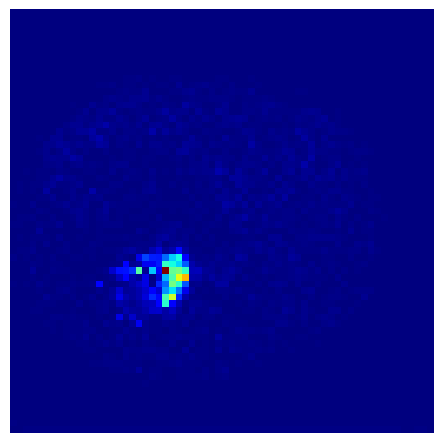

In [ ]:
diff = abs(inputimg.cpu() - current_img[0, 0].cpu()).detach().numpy()
plt.style.use("default")
plt.imshow(diff[0, ...], cmap="jet")
plt.tight_layout()
plt.axis("off")
plt.show()

### Reading the anomaly map

The heat map is most useful as a **relative localization signal** rather than a calibrated probability map. In practice, post-processing may include smoothing, thresholding, connected-component filtering, or comparison against the ground-truth segmentation when quantitative evaluation is required.


# Part II — Classifier-free guidance (CFG)

Classifier-free guidance removes the need for a separate classifier at sampling time. During training, the diffusion model sometimes receives the true class condition and sometimes a special **null condition**. This teaches one network both a conditional predictor and an unconditional predictor.

In this notebook:

- class `0` = diseased
- class `1` = healthy
- class `2` = no-class / unconditional token
- `no_class_prob = 0.1` means 10% of training examples drop the class condition

At sampling time, let $\epsilon_{\text{cond}}$ be the noise prediction for the desired class and $\epsilon_{\text{uncond}}$ the prediction for the null class. CFG combines them as

$$
\epsilon_{\text{CFG}}
=
\epsilon_{\text{uncond}}
+ w\left(\epsilon_{\text{cond}}-\epsilon_{\text{uncond}}\right)
=
w\epsilon_{\text{cond}} + (1-w)\epsilon_{\text{uncond}}.
$$

For $w>1$, the conditional direction is extrapolated beyond the ordinary class-conditioned prediction.


In [ ]:
device = torch.device("cuda")

num_classes = 3       # diseased, healthy, and the null/unconditional class
no_class_prob = 0.1  # probability of dropping the true class during training
no_class_val = 2     # embedding index reserved for the null condition
cross_attn_dim = 1   # dimensionality of the learned class embedding

model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(64, 64, 64),
    attention_levels=(False, False, True),
    num_res_blocks=1,
    num_head_channels=64,
    with_conditioning=True,
    cross_attention_dim=cross_attn_dim
)
model.to(device)

scheduler = DDIMScheduler(num_train_timesteps=1000)

optimizer = torch.optim.Adam(params=model.parameters(), lr=2.5e-5)

inferer = DiffusionInferer(scheduler)

# Learned scalar embedding passed to the U-Net through cross-attention.
class_embed = torch.nn.Embedding(num_embeddings=num_classes, embedding_dim=cross_attn_dim).to(device)


Epoch 0 Validation loss 0.48741817474365234
Epoch 20 Validation loss 0.21869635581970215
Epoch 40 Validation loss 0.08043598383665085
Epoch 60 Validation loss 0.028941579163074493
Epoch 80 Validation loss 0.01615307107567787
Epoch 100 Validation loss 0.009378944523632526
Epoch 120 Validation loss 0.019436782225966454
Epoch 140 Validation loss 0.00796346366405487
Epoch 160 Validation loss 0.01034662313759327
Epoch 180 Validation loss 0.01042214035987854
Epoch 200 Validation loss 0.015718020498752594
Epoch 220 Validation loss 0.005430513061583042
Epoch 240 Validation loss 0.012419665232300758
Epoch 260 Validation loss 0.012108078226447105
Epoch 280 Validation loss 0.006067141890525818
Epoch 300 Validation loss 0.01111324317753315
Epoch 320 Validation loss 0.013636311516165733
Epoch 340 Validation loss 0.011808441020548344
Epoch 360 Validation loss 0.025745578110218048
Epoch 380 Validation loss 0.009654534980654716
Epoch 400 Validation loss 0.006846051663160324
Epoch 420 Validation loss 0

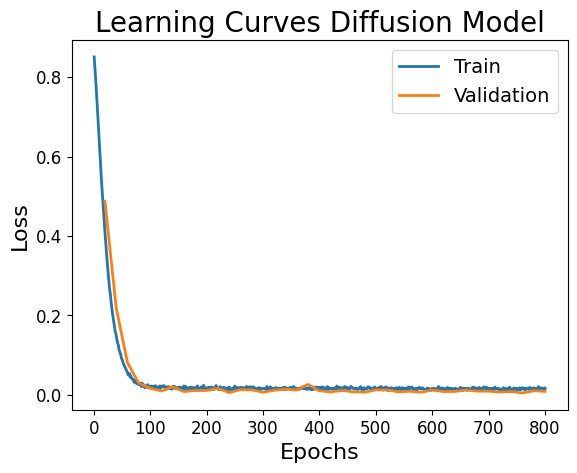

In [ ]:
max_epochs = 800
val_interval = 20
epoch_loss_list = []
val_epoch_loss_list = []

scaler = GradScaler()
total_start = time.time()

for epoch in range(max_epochs):
    model.train()
    len_train_loader = len(train_loader)
    epoch_loss = 0

    for data in train_loader:
        images = data["image"].to(device)

        classes = data["slice_label"].to(device).long()
        # Randomly replace some labels with the null class so one model learns
        # both conditional and unconditional noise prediction.
        no_class_ids = torch.bernoulli(no_class_prob * torch.ones(len(classes), device=device)).bool()
        classes[no_class_ids] = no_class_val
        cond = class_embed(classes).unsqueeze(-1)

        optimizer.zero_grad(set_to_none=True)
        timesteps = torch.randint(0, 1000, (len(images),)).to(device)  # pick a random timestep

        with autocast(enabled=True, device_type="cuda"):
            # Sample the noise to be predicted
            noise = torch.randn_like(images).to(device)

            # Predict noise while conditioning through cross-attention
            noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise,
                                 timesteps=timesteps, condition=cond, mode='crossattn')
            loss = F.mse_loss(noise_pred.float(), noise.float())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()
    epoch_loss_list.append(epoch_loss / (len_train_loader + 1))

    if epoch % val_interval == 0:
        model.eval()
        len_val_loader = len(val_loader)
        val_epoch_loss = 0

        for data in val_loader:
            images = data["image"].to(device)

            classes = data["slice_label"].to(device).long()
            no_class_ids = torch.bernoulli(no_class_prob * torch.ones(len(classes), device=device)).bool()
            classes[no_class_ids] = no_class_val
            cond = class_embed(classes).unsqueeze(-1)

            timesteps = torch.randint(0, 1000, (len(images),)).to(device)
            with torch.no_grad():
                with autocast(enabled=True, device_type="cuda"):
                    noise = torch.randn_like(images).to(device)
                    noise_pred = inferer(inputs=images, diffusion_model=model, noise=noise,
                                         timesteps=timesteps, condition=cond, mode='crossattn')
                    val_loss = F.mse_loss(noise_pred.float(), noise.float())

            val_epoch_loss += val_loss.item()
        val_epoch_loss_list.append(val_epoch_loss / (len_val_loader + 1))
        print("Epoch", epoch, "Validation loss", val_epoch_loss / (len_val_loader + 1))

total_time = time.time() - total_start
print(f"train diffusion completed, total time: {total_time}.")

plt.style.use("default")
plt.title("Learning Curves Diffusion Model", fontsize=20)
plt.plot(np.linspace(1, max_epochs, max_epochs), epoch_loss_list, color="C0", linewidth=2.0, label="Train")
plt.plot(
    np.linspace(val_interval, max_epochs, int(max_epochs / val_interval)),
    val_epoch_loss_list,
    color="C1",
    linewidth=2.0,
    label="Validation",
)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.legend(prop={"size": 14})
plt.show()


### What changes during CFG training?

The diffusion objective itself is unchanged: the model still predicts the injected noise. The difference is that the U-Net now receives a learned class embedding. On roughly 10% of examples, that embedding is replaced with the null-class embedding. This condition dropout is what enables an unconditional prediction to be produced by the same network at inference time.


minmax metatensor(0.) metatensor(1.0693)


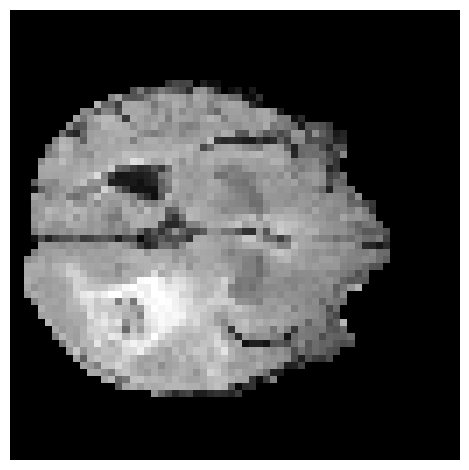

In [ ]:
data_val = next(iter(val_loader))
idx_unhealthy = np.argwhere(data_val["slice_label"].numpy() == 0).squeeze()
idx = idx_unhealthy[4]  # Pick a random slice of the validation set to be transformed
inputimg = data_val["image"][idx]  # Pick an input slice of the validation set to be transformed
inputlabel = data_val["slice_label"][idx]  # Check whether it is healthy or diseased
print("minmax", inputimg.min(), inputimg.max())

plt.figure("input" + str(inputlabel))
plt.imshow(inputimg[0, ...], vmin=0, vmax=1, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

model.eval();

100%|██████████| 200/200 [00:09<00:00, 21.52it/s]


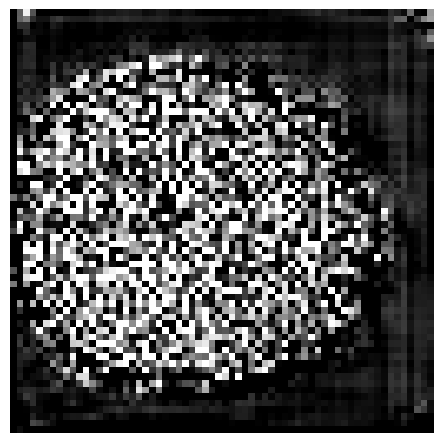

In [ ]:
L = 200
current_img = inputimg[None, ...].to(device)
scheduler.set_timesteps(num_inference_steps=1000)

progress_bar = tqdm(range(L))  # go back and forth L timesteps
for t in progress_bar:  # go through the noising process
    with autocast(enabled=False, device_type="cuda"):
        with torch.no_grad():
            # Invert using the observed/source class (diseased = 0).
            diseased_cond = class_embed(torch.tensor(0).to(device).long()).unsqueeze(-1).unsqueeze(0)
            model_output = model(current_img, timesteps=torch.Tensor((t,)).to(current_img.device),
                                 context=diseased_cond)
    current_img, _ = scheduler.reversed_step(model_output, t, current_img)

plt.style.use("default")
plt.imshow(current_img[0, 0].cpu(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.show()


100%|██████████| 200/200 [00:18<00:00, 10.59it/s]


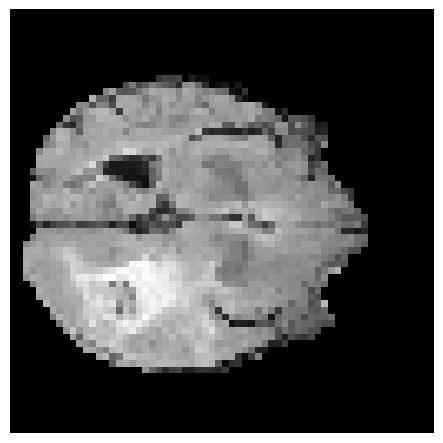

In [ ]:
y = torch.tensor(1)  # target class: healthy
no_class = torch.tensor(2)  # null / unconditional class
w = 2  # CFG scale; w > 1 strengthens the healthy-class direction
progress_bar = tqdm(range(L))  # go back and forth L timesteps

for i in progress_bar:  # go through the denoising process
    t = L - i
    with autocast(enabled=True, device_type="cuda"):
        with torch.no_grad():
            healthy_cond = class_embed(y.to(device).long()).unsqueeze(-1).unsqueeze(0)
            no_class_cond = class_embed(no_class.to(device).long()).unsqueeze(-1).unsqueeze(0)

            model_output_healthy = model(current_img, timesteps=torch.Tensor((t,)).to(current_img.device),
                                         context=healthy_cond).detach()

            model_output_no_class = model(current_img, timesteps=torch.Tensor((t,)).to(current_img.device),
                                         context=no_class_cond).detach()

            # Equivalent to eps_uncond + w * (eps_cond - eps_uncond).
            updated_noise = w * model_output_healthy + (1 - w) * model_output_no_class

    current_img, _ = scheduler.step(updated_noise, t, current_img)
    torch.cuda.empty_cache()

plt.style.use("default")
plt.imshow(current_img[0, 0].cpu().detach().numpy(), vmin=0, vmax=1, cmap="gray")
plt.tight_layout()
plt.axis("off")
plt.show()


### CFG reconstruction result

The cell above computes both the healthy-conditioned and null-conditioned noise estimates at every denoising step, then extrapolates toward the healthy condition using `w = 2`. The resulting image is the classifier-free-guided healthy reconstruction used for the final anomaly map.


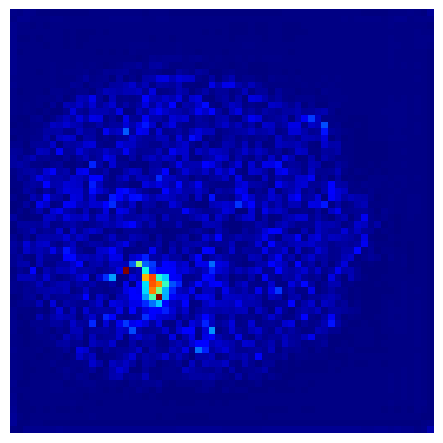

In [ ]:
# Pixel-wise reconstruction difference: high values are candidate anomalies.
diff = abs(inputimg.cpu() - current_img[0, 0].cpu()).detach().numpy()
plt.style.use("default")
plt.imshow(diff[0, ...], cmap="jet")
plt.tight_layout()
plt.axis("off")
plt.show()


In [ ]:
torch.save(model.state_dict(), 'monai_cfg.pth')